In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# ตั้งค่าการแสดงผลเบื้องต้น
pd.options.display.max_columns = None

In [2]:
# โหลดข้อมูล (จัดการหลักพันที่มีคอมม่า)
file_path = "/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv"
df = pd.read_csv(file_path, thousands=',', decimal='.')

# เช็คข้อมูลเบื้องต้น
df.head()

,วันเดือนปี,ล่าสุด,ราคาเปิด,สูงสุด,ต่ำสุด,ปริมาณ,% เปลี่ยน
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%
2,03/11/2026,1994.77,2005.44,2027.22,1994.77,3.28B,0.05%
3,03/10/2026,1993.83,2002.12,2011.29,1974.74,3.24B,1.57%
4,03/09/2026,1962.94,1904.99,1967.94,1887.28,4.25B,-2.02%


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   วันเดือนปี  3554 non-null   object 
 1   ล่าสุด      3554 non-null   float64
 2   ราคาเปิด    3554 non-null   float64
 3   สูงสุด      3554 non-null   float64
 4   ต่ำสุด      3554 non-null   float64
 5   ปริมาณ      3554 non-null   object 
 6   % เปลี่ยน   3554 non-null   object 
dtypes: float64(4), object(3)
memory usage: 194.5+ KB
None


In [ ]:
# คาดการณ์ลำดับ: วันเดือนปี, ล่าสุด, ราคาเปิด, สูงสุด, ต่ำสุด, ปริมาณ, % เปลี่ยน
df.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct']
df.head(2)

,Date,Close,Open,High,Low,Volume,Change_Pct
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%


In [5]:
# แปลงเป็น datetime และเรียงจากเก่าไปใหม่ (สำคัญมากสำหรับ Wyckoff)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1.90M,-0.98%
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2.03M,1.65%
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1.96M,-0.30%
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2.32M,-2.04%
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1.89M,-0.08%


In [6]:
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.upper()
        if 'B' in vol_str: return float(vol_str.replace('B', '')) * 1e9
        if 'M' in vol_str: return float(vol_str.replace('M', '')) * 1e6
        if 'K' in vol_str: return float(vol_str.replace('K', '')) * 1e3
    return vol_str

df['Volume'] = df['Volume'].apply(convert_volume)
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1900000.0,-0.98%
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2030000.0,1.65%
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1960000.0,-0.30%
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2320000.0,-2.04%
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1890000.0,-0.08%


In [7]:
# เช็คค่าว่าง
print("Missing values:\n", df.isnull().sum())

Missing values:
 Date          0
Close         0
Open          0
High          0
Low           0
Volume        0
Change_Pct    0
dtype: int64


In [8]:
# เช็ค Volume หรือ Price เป็น 0
zero_counts = (df[['Close', 'Volume']] == 0).sum()
print("\nZero values in Close/Volume:\n", zero_counts)


Zero values in Close/Volume:
 Close     0
Volume    0
dtype: int64


In [26]:
# ทำความสะอาด (ลบแถวที่มีปัญหา)
df = df.dropna()
df = df[df['Volume'] > 0]
df.reset_index(drop=True, inplace=True)

In [10]:
# Spread & Close Position
df['Spread'] = df['High'] - df['Low']
df['Close_Pos'] = (df['Close'] - df['Low']) / (df['Spread'] + 1e-6)

# Shadows
df['Lower_Shadow'] = df[['Open', 'Close']].min(axis=1) - df['Low']
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)

# Volume Analysis
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()
df['Rel_Vol'] = df['Volume'] / (df['Vol_MA20'] + 1e-6)

# Price vs Volume Divergence
df['Spread_MA20'] = df['Spread'].rolling(window=20).mean()
df['Rel_Spread'] = df['Spread'] / (df['Spread_MA20'] + 1e-6)

# เทรนราคา (เพื่อแยกฝั่ง Acc/Dist)
df['Price_Trend'] = df['Close'].diff(5)

In [11]:
# หาแนวรับแนวต้านย้อนหลัง 50 แท่ง
window_tr = 120
df['Support_TR'] = df['Low'].rolling(window=window_tr).min().shift(1)
df['Resistance_TR'] = df['High'].rolling(window=window_tr).max().shift(1)

# ระยะห่างจากแนวรับ (%)
df['Dist_from_Sup'] = (df['Low'] - df['Support_TR']) / (df['Support_TR'] + 1e-6)
df['Dist_from_Res'] = (df['High'] - df['Resistance_TR']) / (df['Resistance_TR'] + 1e-6)

In [12]:
df.head()

,Date,Close,Open,High,Low,Volume,Change_Pct,Spread,Close_Pos,Lower_Shadow,Upper_Shadow,Vol_MA20,Rel_Vol,Spread_MA20,Rel_Spread,Price_Trend,Support_TR,Resistance_TR,Dist_from_Sup,Dist_from_Res
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,1900000.0,-0.98%,24.10,0.000000,0.00,0.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,2030000.0,1.65%,17.90,0.827374,1.99,3.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,1960000.0,-0.30%,23.60,0.078390,1.85,6.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,2320000.0,-2.04%,22.54,0.223159,5.03,10.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,1890000.0,-0.08%,28.32,0.950212,26.91,0.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("สร้าง Features เรียบร้อยแล้ว! คอลัมน์ที่มีตอนนี้คือ:")
print(df.columns.tolist())

สร้าง Features เรียบร้อยแล้ว! คอลัมน์ที่มีตอนนี้คือ:
['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct', 'Spread', 'Close_Pos', 'Lower_Shadow', 'Upper_Shadow', 'Vol_MA20', 'Rel_Vol', 'Spread_MA20', 'Rel_Spread', 'Price_Trend', 'Support_TR', 'Resistance_TR', 'Dist_from_Sup', 'Dist_from_Res']


In [14]:
# --- Logic: Accumulation (Phase A-E) Updated --- #

# 1. กำหนดตัวแปรควบคุม (พารามิเตอร์)
THRESHOLD_SC_VOL = 1.3      
THRESHOLD_SOS_VOL = 1.1     
THRESHOLD_SPRING_POS = 0.4  # ปรับให้ยืดหยุ่นขึ้น (ดึงกลับ 40% ของแท่ง)
THRESHOLD_LPS_VOL = 0.9     

df['Wyckoff_Event'] = ""
last_sc_idx = -1

# เริ่ม Loop (ใช้ window_tr เพื่อให้แน่ใจว่ามีข้อมูล Support/Resistance แล้ว)
for i in range(window_tr + 1, len(df)):
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    low       = df.loc[i, 'Low']
    high      = df.loc[i, 'High']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']
    dist_sup  = df.loc[i, 'Dist_from_Sup']

    # --- 1. Phase A: Stop the Downward Trend ---
    if rel_vol > THRESHOLD_SC_VOL and trend < 0:
        if close_pos > 0.15:
            df.at[i, 'Wyckoff_Event'] = "SC"
            last_sc_idx = i
        else:
            df.at[i, 'Wyckoff_Event'] = "PS"

    # --- 2. Phase A/B: Automatic Rally & Secondary Test ---
    elif last_sc_idx != -1 and i < last_sc_idx + 15:
        # AR: จุดสูงสุดแรกหลัง SC
        if close > df.loc[i-1, 'Close'] and high == df.loc[last_sc_idx:i+1, 'High'].max():
            df.at[i, 'Wyckoff_Event'] = "AR"
        # ST: การกลับลงมาทดสอบแถวๆ แนวรับ SC
        elif low < (sup * 1.02) and rel_vol < rel_vol * 0.8: # Vol ต้องน้อยลงกว่าตอน SC
            df.at[i, 'Wyckoff_Event'] = "ST"

    # --- 3. Phase C: The Spring / Shakeout (จุดเปลี่ยนสำคัญ) ---
    # ใช้ sup ที่ shift(1) มาแล้ว ดังนั้น low < sup จะเป็นจริงเมื่อราคาหลุดแนวรับเดิม
    elif low < sup:
        if close_pos > THRESHOLD_SPRING_POS:
            df.at[i, 'Wyckoff_Event'] = "SPRING"
        else:
            # ถ้าหลุดแล้วไม่ดึงกลับ ให้มองเป็น ST อีกรูปแบบหนึ่ง หรือ SOW ในกรอบ
            df.at[i, 'Wyckoff_Event'] = "ST"
            
    # TEST: เกิดหลัง SPRING โดยต้องมี Volume ที่ "แห้ง" มากๆ
    elif rel_vol < 0.8 and abs(dist_sup) < 0.01:
        if "SPRING" in df.loc[i-30:i, 'Wyckoff_Event'].values:
            df.at[i, 'Wyckoff_Event'] = "TEST"

    # --- 4. Phase D/E: SOS, BU & LPS ---
    # SOS: ทะลุแนวต้าน Resistance_TR (ที่ shift มาแล้ว)
    elif close > res and rel_vol > THRESHOLD_SOS_VOL:
        df.at[i, 'Wyckoff_Event'] = "SOS"
        
    elif i > 0 and "SOS" in df.loc[i-5:i, 'Wyckoff_Event'].values and close <= res:
        df.at[i, 'Wyckoff_Event'] = "BU"

    elif trend > 0 and close_pos > 0.6 and low > sup:
        is_higher_low = low > df.loc[i-10:i, 'Low'].min()
        is_low_vol    = rel_vol < THRESHOLD_LPS_VOL
        is_upper_zone = close > (sup + (res - sup) * 0.6)
        
        if is_higher_low and is_low_vol and is_upper_zone:
            if "LPS" not in df.loc[i-5:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "LPS"
# ตรวจสอบผลลัพธ์
event_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
df[df['Wyckoff_Event'].isin(event_list)].tail(10)

,Date,Close,Open,High,Low,Volume,Change_Pct,Spread,Close_Pos,Lower_Shadow,Upper_Shadow,Vol_MA20,Rel_Vol,Spread_MA20,Rel_Spread,Price_Trend,Support_TR,Resistance_TR,Dist_from_Sup,Dist_from_Res,Wyckoff_Event
3538,2026-02-19,2146.63,2117.84,2149.64,2114.27,4.730000e+09,1.81%,35.37,0.914900,3.57,3.01,3.232500e+09,1.463264,25.5740,1.383045,72.66,1722.01,2114.22,0.227792,0.016753,SOS
3539,2026-02-20,2126.50,2143.23,2148.01,2117.21,5.110000e+09,-0.94%,30.80,0.301623,9.29,4.78,3.343000e+09,1.528567,25.9160,1.188455,66.67,1722.01,2149.64,0.229499,-0.000758,BU
3540,2026-02-23,2121.19,2137.12,2157.10,2103.06,4.630000e+09,-0.25%,54.04,0.335492,18.13,19.98,3.451500e+09,1.341446,27.8485,1.940499,52.53,1722.01,2149.64,0.221282,0.003470,BU
3541,2026-02-24,2138.81,2122.16,2142.17,2101.89,3.520000e+09,0.83%,40.28,0.916584,20.27,3.36,3.502000e+09,1.005140,27.9810,1.439548,39.16,1722.01,2157.10,0.220603,-0.006921,BU
3542,2026-02-25,2172.74,2161.53,2183.43,2155.90,3.980000e+09,1.59%,27.53,0.611696,5.63,10.69,3.584000e+09,1.110491,28.5100,0.965626,64.21,1722.01,2157.10,0.251967,0.012206,SOS
3543,2026-02-26,2194.96,2186.40,2198.56,2175.39,3.170000e+09,1.02%,23.17,0.844627,11.01,3.60,3.623500e+09,0.874845,28.5295,0.812142,48.33,1742.74,2183.43,0.248258,0.006929,LPS
3544,2026-02-27,2182.04,2177.08,2209.50,2173.40,3.900000e+09,-0.59%,36.10,0.239335,3.68,27.46,3.705500e+09,1.052490,29.6090,1.219224,55.54,1745.35,2198.56,0.245252,0.004976,BU
3545,2026-03-02,2090.76,2126.81,2155.59,2090.76,5.430000e+09,-4.18%,64.83,0.000000,0.00,28.78,3.871500e+09,1.402557,31.7450,2.042211,-30.43,1745.35,2209.50,0.197903,-0.024399,PS
3546,2026-03-04,1975.04,1984.99,2000.82,1906.75,7.390000e+09,-5.53%,94.07,0.725949,68.29,15.83,4.104000e+09,1.800682,34.8375,2.700251,-163.77,1745.35,2209.50,0.092474,-0.094447,SC
3547,2026-03-05,2015.28,2032.63,2036.70,1969.42,5.150000e+09,2.04%,67.28,0.681629,45.86,4.07,4.252000e+09,1.211195,37.4675,1.795690,-157.46,1745.35,2209.50,0.128381,-0.078208,AR


In [15]:
# --- 1. กำหนดตัวแปรควบคุม (Parameters) สำหรับ Distribution ---
THRESHOLD_BC_VOL = 1.3       # ลดจาก 1.8 เพื่อให้จับ Buying Climax ได้ง่ายขึ้นใน SET 100
THRESHOLD_SOW_VOL = 1.1      # Volume เมื่อหลุดแนวรับ (Sign of Weakness)
THRESHOLD_LPSY_VOL = 0.9     # Volume ต้อง "แห้ง" (แรงซื้อไม่มี) สำหรับ LPSY

last_bc_idx = -1

for i in range(10, len(df)):
    if df.loc[i, 'Wyckoff_Event'] != "": continue # ข้ามถ้ามี Event อื่นอยู่แล้ว
    
    # ดึงค่าปัจจุบันมาพักไว้
    rel_vol   = df.loc[i, 'Rel_Vol']
    close_pos = df.loc[i, 'Close_Pos']
    trend     = df.loc[i, 'Price_Trend']
    high      = df.loc[i, 'High']
    close     = df.loc[i, 'Close']
    sup       = df.loc[i, 'Support_TR']
    res       = df.loc[i, 'Resistance_TR']

    # 1. Phase A: PSY & BC (Preliminary Supply & Buying Climax)
    if rel_vol > THRESHOLD_BC_VOL and trend > 0:
        if close_pos < 0.85: # ปิดไม่สูงมาก แสดงว่าเริ่มมีแรงขายกด
            df.at[i, 'Wyckoff_Event'] = "BC"
            last_bc_idx = i
        else:
            df.at[i, 'Wyckoff_Event'] = "PSY"

    # 2. Phase A/B: AR & ST (Automatic Reaction & Secondary Test)
    elif last_bc_idx != -1 and i < last_bc_idx + 15:
        if close < df.loc[i-1, 'Close'] and df.loc[i, 'Low'] == df.loc[last_bc_idx:i+1, 'Low'].min():
            df.at[i, 'Wyckoff_Event'] = "AR_Dist"

    # 3. Phase C: UT & UTAD (Upthrust)
    elif high > res and close < res:
        if close_pos < 0.4: # หลอกว่าทะลุแล้วดึงกลับลงมาปิดต่ำ
            df.at[i, 'Wyckoff_Event'] = "UTAD" if i > last_bc_idx + 20 else "UT"

    # 4. Phase D/E: SOW (Sign of Weakness)
    elif close < sup and rel_vol > THRESHOLD_SOW_VOL:
        df.at[i, 'Wyckoff_Event'] = "SOW"

    # 5. Phase D: LPSY (Last Point of Supply) - ปรับปรุงให้เข้มงวดขึ้น
    elif trend < 0 and close_pos < 0.4 and high < res:
        is_lower_high = high < df.loc[i-5:i, 'High'].max()
        is_low_vol    = rel_vol < THRESHOLD_LPSY_VOL
        is_lower_zone = close < (sup + (res - sup) * 0.4)
        
        if is_lower_high and is_low_vol and is_lower_zone:
            # ป้องกันไม่ให้ขึ้นติดกันเกินไป (ต้องเว้นอย่างน้อย 5 วัน)
            if "LPSY" not in df.loc[i-5:i, 'Wyckoff_Event'].values:
                df.at[i, 'Wyckoff_Event'] = "LPSY"

# ดูผลลัพธ์ Distribution
dist_list = ['BC', 'UTAD', 'SOW', 'LPSY']
df[df['Wyckoff_Event'].isin(dist_list)].tail(10)

,Date,Close,Open,High,Low,Volume,Change_Pct,Spread,Close_Pos,Lower_Shadow,Upper_Shadow,Vol_MA20,Rel_Vol,Spread_MA20,Rel_Spread,Price_Trend,Support_TR,Resistance_TR,Dist_from_Sup,Dist_from_Res,Wyckoff_Event
3318,2025-03-21,1631.80,1628.70,1634.21,1620.62,3.750000e+09,0.77%,13.59,0.822664,8.08,2.41,2.531000e+09,1.481628,30.7760,0.441578,21.61,1585.20,2096.93,0.022344,-0.220665,BC
3357,2025-05-23,1638.41,1641.47,1652.30,1634.22,1.990000e+09,0.25%,18.08,0.231748,4.19,10.83,2.426000e+09,0.820280,25.2160,0.717005,-25.55,1439.14,2035.50,0.135553,-0.188258,LPSY
3366,2025-06-09,1574.21,1586.32,1589.71,1570.06,1.580000e+09,-0.17%,19.65,0.211196,4.15,3.39,2.424000e+09,0.651815,23.5710,0.833651,-44.51,1439.14,2035.50,0.090971,-0.219008,LPSY
3372,2025-06-17,1546.32,1553.37,1555.53,1544.43,1.470000e+09,-0.16%,11.10,0.170270,1.89,2.16,2.263000e+09,0.649580,20.4760,0.542098,-34.96,1439.14,1992.01,0.073162,-0.219115,LPSY
3378,2025-06-25,1544.92,1524.59,1550.50,1518.06,3.520000e+09,0.80%,32.44,0.827990,6.53,5.58,2.468000e+09,1.426256,23.8685,1.359113,27.90,1439.14,1978.14,0.054838,-0.216183,BC
3403,2025-08-01,1706.62,1760.20,1764.96,1705.03,3.750000e+09,-2.21%,59.93,0.026531,1.59,4.76,2.494000e+09,1.503609,29.7185,2.016589,8.12,1439.14,1885.29,0.184756,-0.063826,BC
3406,2025-08-06,1766.86,1758.05,1771.63,1748.09,3.740000e+09,1.08%,23.54,0.797366,9.96,4.77,2.643000e+09,1.415059,30.2935,0.777064,19.31,1439.14,1843.79,0.214677,-0.039137,BC
3407,2025-08-07,1768.58,1775.12,1793.09,1761.21,3.650000e+09,0.10%,31.88,0.231179,7.37,17.97,2.734000e+09,1.335040,31.0190,1.027757,23.40,1439.14,1827.77,0.223793,-0.018974,BC
3505,2026-01-05,1815.53,1804.89,1826.19,1801.46,2.480000e+09,1.52%,24.73,0.568945,3.43,10.66,1.791146e+09,1.384588,19.2270,1.286212,6.16,1533.98,1880.65,0.174370,-0.028958,BC
3516,2026-01-20,1857.06,1838.81,1870.81,1837.61,2.750000e+09,1.08%,33.20,0.585843,1.20,13.75,1.851146e+09,1.485566,20.8365,1.593358,94.26,1665.18,1880.65,0.103550,-0.005232,BC


In [16]:
detected = df[df['Wyckoff_Event'] != ""].copy()

# ตรวจสอบว่าคอลัมน์ Date เป็น datetime หรือไม่ (กัน Error .dt.days)
if not pd.api.types.is_datetime64_any_dtype(df.index):
    detected['Date_Col'] = pd.to_datetime(detected.index)
else:
    detected['Date_Col'] = detected.index

# คำนวณระยะห่างระหว่าง Event (วัน)
detected['Days_Since_Last'] = detected['Date_Col'].diff().dt.days

In [17]:
# --- 2. ส่วนของ Accumulation Summary ---
acc_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
acc_stats = detected[detected['Wyckoff_Event'].isin(acc_list)].copy()

print("=== [COUNT] Accumulation Summary ===")
if not acc_stats.empty:
    print(acc_stats['Wyckoff_Event'].value_counts().sort_index())
    print(f"\nTotal Acc Events: {len(acc_stats)}")
else:
    print("No Accumulation events found.")

=== [COUNT] Accumulation Summary ===
Wyckoff_Event
AR         74
BU        136
LPS        72
PS         62
SC        128
SOS        50
SPRING     13
ST         17
TEST        2
Name: count, dtype: int64

Total Acc Events: 554


In [18]:
# --- 3. ส่วนของ Distribution Summary ---
dist_list = ['PSY', 'BC', 'AR_Dist', 'ST_Dist', 'UT', 'UTAD', 'SOW', 'LPSY']
dist_stats = detected[detected['Wyckoff_Event'].isin(dist_list)].copy()

print("=== [COUNT] Distribution Summary ===")
if not dist_stats.empty:
    print(dist_stats['Wyckoff_Event'].value_counts().sort_index())
    print(f"\nTotal Dist Events: {len(dist_stats)}")
else:
    print("No Distribution events found.")

=== [COUNT] Distribution Summary ===
Wyckoff_Event
AR_Dist     75
BC         155
LPSY        58
PSY         58
SOW          6
UT           7
UTAD        13
Name: count, dtype: int64

Total Dist Events: 372


In [19]:
# 3. สรุปผลแยกตาม Event Type
print("=== Event Summary Statistics ===")
print(detected['Wyckoff_Event'].value_counts())

=== Event Summary Statistics ===
Wyckoff_Event
BC         155
BU         136
SC         128
AR_Dist     75
AR          74
LPS         72
PS          62
PSY         58
LPSY        58
SOS         50
ST          17
UTAD        13
SPRING      13
UT           7
SOW          6
TEST         2
Name: count, dtype: int64


In [20]:
# 4. แสดง 15 เหตุการณ์ล่าสุด
print("\n=== Latest 15 Events ===")
print(detected[['Date', 'Close', 'Rel_Vol', 'Close_Pos', 'Wyckoff_Event']].tail(15))

# เช็คผลตอบแทนหลังเกิด SPRING (Phase C) ภายใน 10 วัน
spring_idxs = df[df['Wyckoff_Event'] == "SPRING"].index
if len(spring_idxs) > 0:
    results = []
    for idx in spring_idxs:
        current_idx = df.index.get_loc(idx)
        if current_idx + 10 < len(df):
            ret = (df.iloc[current_idx + 10]['Close'] - df.iloc[current_idx]['Close']) / df.iloc[current_idx]['Close']
            results.append(ret > 0)
    
    if results:
        win_rate = (sum(results) / len(results)) * 100
        print(f"Spring Win Rate (Price up in 10 days): {win_rate:.2f}% (from {len(results)} events)")
else:
    print("No SPRING events to calculate Win Rate.")


=== Latest 15 Events ===
           Date    Close   Rel_Vol  Close_Pos Wyckoff_Event
3533 2026-02-12  2073.97  1.451943   1.000000           SOS
3534 2026-02-13  2059.83  1.385582   0.272930            BU
3535 2026-02-16  2068.66  0.998369   0.313330            BU
3536 2026-02-17  2099.65  1.323764   0.954055           SOS
3537 2026-02-18  2108.53  1.327892   0.728141           SOS
3538 2026-02-19  2146.63  1.463264   0.914900           SOS
3539 2026-02-20  2126.50  1.528567   0.301623            BU
3540 2026-02-23  2121.19  1.341446   0.335492            BU
3541 2026-02-24  2138.81  1.005140   0.916584            BU
3542 2026-02-25  2172.74  1.110491   0.611696           SOS
3543 2026-02-26  2194.96  0.874845   0.844627           LPS
3544 2026-02-27  2182.04  1.052490   0.239335            BU
3545 2026-03-02  2090.76  1.402557   0.000000            PS
3546 2026-03-04  1975.04  1.800682   0.725949            SC
3547 2026-03-05  2015.28  1.211195   0.681629            AR
Spring Win Rat

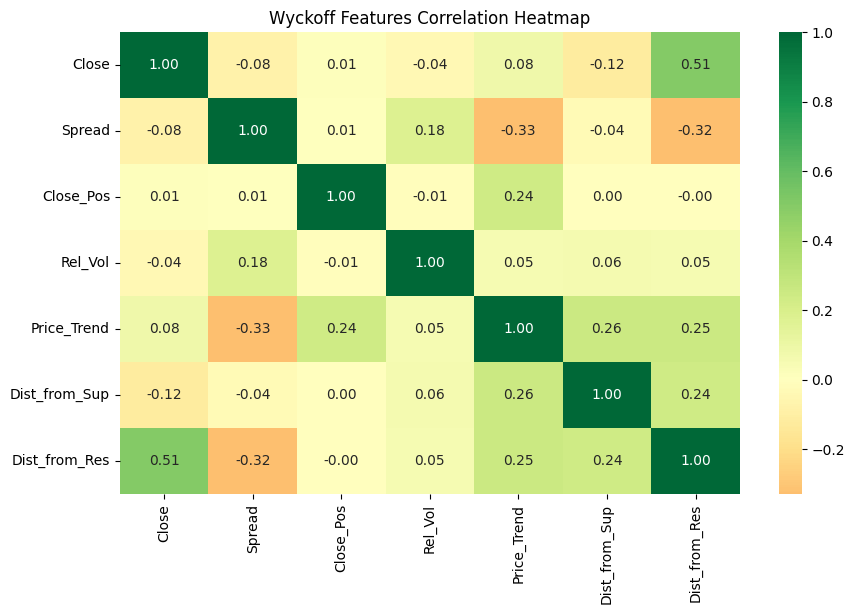

In [21]:
plt.figure(figsize=(10, 6))
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขและมีนัยสำคัญต่อ Wyckoff
feat_cols = ['Close', 'Spread', 'Close_Pos', 'Rel_Vol', 'Price_Trend', 'Dist_from_Sup', 'Dist_from_Res']
sns.heatmap(df[feat_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title("Wyckoff Features Correlation Heatmap")
plt.show()

In [22]:
# --- Visualization: Full Accumulation Phase A-E --- #

# 1. กำหนดรายชื่อ Event ให้ครบทุก Phase
acc_events = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']

# 2. ปรับช่วงข้อมูลให้ยาวขึ้น (เช่น 500 วัน) เพื่อให้เห็นครบทุก Phase (A-E)
dfpl = df.tail(700).copy() 

# 3. สร้าง Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05, 
                    row_heights=[0.7, 0.3],
                    subplot_titles=('SET 100 Wyckoff Accumulation: Phase A-E', 'Volume Analysis'))

# --- กราฟบน: Candlestick & TR Lines ---
fig.add_trace(go.Candlestick(x=dfpl.index, open=dfpl['Open'], high=dfpl['High'], 
                             low=dfpl['Low'], close=dfpl['Close'], name='Price'), row=1, col=1)

# เส้น Trading Range (หัวใจของ Phase B)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Support_TR'], 
                         line=dict(color='rgba(255, 100, 100, 0.4)', dash='dash'), name='Support'), row=1, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Resistance_TR'], 
                         line=dict(color='rgba(100, 255, 100, 0.4)', dash='dash'), name='Resistance'), row=1, col=1)

# 4. การจัดการ Annotations ให้กระจายตัวตาม Phase
event_df = dfpl[dfpl['Wyckoff_Event'].isin(acc_events)]

for idx, row in event_df.iterrows():
    e_name = row['Wyckoff_Event']
    
    # แยกสีตามความสำคัญของ Phase
    if e_name in ['SC', 'SPRING']: # จุดกลับตัวหลัก
        bg_color = "#FF00FF" # สีชมพูเข้ม
    elif e_name in ['SOS', 'BU']: # จุดยืนยันขาขึ้น (Phase D-E)
        bg_color = "#00FF00" # สีเขียว
    else:
        bg_color = "#1f77b4" # สีน้ำเงินมาตรฐาน
    
    # กำหนดตำแหน่งวาง Label
    is_high = e_name in ['AR', 'SOS', 'BU']
    y_pos = row['High'] if is_high else row['Low']
    ay_val = -50 if is_high else 50
    
    fig.add_annotation(
        x=idx, y=y_pos, text=f"<b>{e_name}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        ax=0, ay=ay_val, bgcolor=bg_color,
        font=dict(color="white" if bg_color != "#00FF00" else "black", size=10)
    )

# --- กราฟล่าง: Volume & Climax ---
vol_colors = ['#26a69a' if c >= o else '#ef5350' for c, o in zip(dfpl['Close'], dfpl['Open'])]
fig.add_trace(go.Bar(x=dfpl.index, y=dfpl['Volume'], name='Volume', marker_color=vol_colors), row=2, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Vol_MA20'], line=dict(color='yellow', width=1), name='Vol MA'), row=2, col=1)

fig.update_layout(height=900, template='plotly_dark', xaxis_rangeslider_visible=False)
fig.show()

In [23]:
# --- Visualization: Full Distribution Phase A-E --- #

# 1. รายชื่อ Event ฝั่ง Distribution ครบทุกเฟส
dist_events = ['PSY', 'BC', 'AR_Dist', 'ST', 'UT', 'UTAD', 'SOW', 'LPSY']

# 2. ขยายช่วงข้อมูลเป็น 500 วัน (เพื่อให้ครอบคลุม Phase A ถึง E)
# การใช้แค่ 100-300 วันอาจเห็นไม่ครบทั้งรอบวงจร
dfpl = df.tail(700).copy()

# 3. สร้าง Figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05, 
                    row_heights=[0.7, 0.3], 
                    subplot_titles=('SET 100 Wyckoff Distribution: Phase A-E', 'Volume Analysis'))

# --- กราฟบน: ราคา และ Trading Range ---
fig.add_trace(go.Candlestick(x=dfpl.index, open=dfpl['Open'], high=dfpl['High'], 
                             low=dfpl['Low'], close=dfpl['Close'], name='Price'), row=1, col=1)

# เส้นแนวรับ-แนวต้าน (กรอบที่รายใหญ่ใช้ระบายของ)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Support_TR'], 
                         line=dict(color='rgba(255, 100, 100, 0.4)', dash='dash'), 
                         name='Support'), row=1, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Resistance_TR'], 
                         line=dict(color='rgba(100, 255, 100, 0.4)', dash='dash'), 
                         name='Resistance'), row=1, col=1)

# กรอง Event
event_df = dfpl[dfpl['Wyckoff_Event'].isin(dist_events)]

# เพิ่ม Annotations แยกสีตามความสำคัญ
for idx, row in event_df.iterrows():
    e_name = row['Wyckoff_Event']
    
    # กำหนดสี: UTAD และ SOW เป็นสีแดงเข้ม (จุดเปลี่ยนสำคัญ)
    if e_name in ['UTAD', 'SOW']:
        bg_color = "#FF0000" # แดง
    elif e_name in ['BC', 'PSY', 'LPSY']:
        bg_color = "#FF8C00" # ส้มเข้ม
    else:
        bg_color = "#FFA500" # ส้มมาตรฐาน
    
    # ตำแหน่งการวาง
    # จุดที่ทดสอบด้านบน: BC, PSY, UT, UTAD
    # จุดที่ทดสอบด้านล่าง: AR_Dist, SOW, LPSY
    is_bottom = e_name in ['AR_Dist', 'SOW', 'LPSY']
    y_pos = row['Low'] if is_bottom else row['High']
    ay_val = 50 if is_bottom else -50
    
    fig.add_annotation(
        x=idx, y=y_pos,
        text=f"<b>{e_name}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        ax=0, ay=ay_val,
        bgcolor=bg_color,
        font=dict(color="white", size=10),
        bordercolor="white"
    )

# --- กราฟล่าง: Volume ---
vol_colors = ['#26a69a' if c >= o else '#ef5350' for c, o in zip(dfpl['Close'], dfpl['Open'])]
fig.add_trace(go.Bar(x=dfpl.index, y=dfpl['Volume'], name='Volume', 
                     marker_color=vol_colors, opacity=0.7), row=2, col=1)

fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['Vol_MA20'], 
                         line=dict(color='yellow', width=1.2), name='Vol MA'), row=2, col=1)

# ปรับแต่ง Layout
fig.update_layout(
    height=900,
    template='plotly_dark',
    xaxis_rangeslider_visible=False,
    showlegend=True
)

fig.show()

In [24]:
# กรองเฉพาะ Event ฝั่งสะสม
acc_list = ['PS', 'SC', 'AR', 'ST', 'SPRING', 'TEST', 'LPS', 'SOS', 'BU']
df_acc = df[df['Wyckoff_Event'].isin(acc_list)].copy()

print("=== Wyckoff Accumulation Summary Table ===")
df_acc[['Close', 'Rel_Vol', 'Close_Pos','Wyckoff_Event', 'Support_TR', 'Resistance_TR']].tail(20)

=== Wyckoff Accumulation Summary Table ===


,Close,Rel_Vol,Close_Pos,Wyckoff_Event,Support_TR,Resistance_TR
3525,1882.03,0.908895,0.940751,BU,1711.65,1911.59
3526,1903.72,1.159788,0.376164,BU,1711.65,1911.59
3530,2008.83,2.518741,0.657751,SOS,1711.65,1951.42
3531,2026.85,1.296667,0.856576,SOS,1711.65,2020.09
3532,2026.44,1.194557,0.324309,BU,1711.65,2029.38
3533,2073.97,1.451943,1.000000,SOS,1711.65,2038.17
3534,2059.83,1.385582,0.272930,BU,1711.65,2073.97
3535,2068.66,0.998369,0.313330,BU,1722.01,2079.41
3536,2099.65,1.323764,0.954055,SOS,1722.01,2084.68
3537,2108.53,1.327892,0.728141,SOS,1722.01,2101.44


In [25]:
# กรองเฉพาะ Event ฝั่งระบายของ
dist_list = ['PSY', 'BC', 'AR_Dist', 'ST', 'UT', 'UTAD', 'SOW', 'LPSY']
df_dist = df[df['Wyckoff_Event'].isin(dist_list)].copy()

print("=== Wyckoff Distribution Summary Table ===")
df_dist[['Close', 'Rel_Vol', 'Close_Pos','Wyckoff_Event', 'Support_TR', 'Resistance_TR']].tail(20)

=== Wyckoff Distribution Summary Table ===


,Close,Rel_Vol,Close_Pos,Wyckoff_Event,Support_TR,Resistance_TR
3307,1635.63,0.857461,0.137429,LPSY,1611.29,2096.93
3314,1603.08,0.698080,0.309405,LPSY,1585.20,2096.93
3318,1631.80,1.481628,0.822664,BC,1585.20,2096.93
3324,1592.85,1.214403,0.211964,AR_Dist,1585.20,2096.93
3357,1638.41,0.820280,0.231748,LPSY,1439.14,2035.50
3366,1574.21,0.651815,0.211196,LPSY,1439.14,2035.50
3372,1546.32,0.649580,0.170270,LPSY,1439.14,1992.01
3378,1544.92,1.426256,0.827990,BC,1439.14,1978.14
3380,1501.75,0.921236,0.154353,AR_Dist,1439.14,1978.14
3401,1747.55,1.480388,0.874424,PSY,1439.14,1895.21
